# Import essential libraries


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [8]:
print(df.info())
print(df.isnull().sum())
print(df.dropna(inplace=True))

print("\n After Removing null values")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
None
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64
None

 After Removing null values
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [9]:
print("Duplicates values:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates values:",df.duplicated().sum())

Duplicates values: 49
Duplicates values: 0


In [10]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

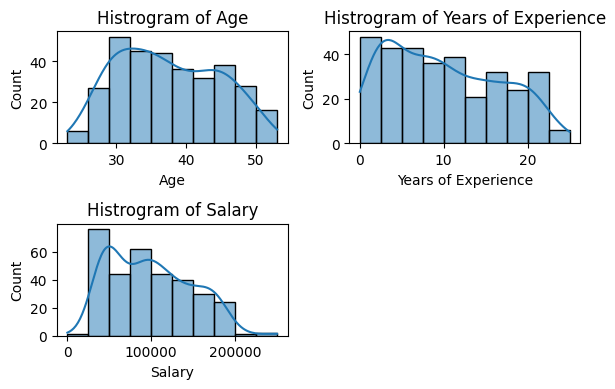

In [11]:
data = ["Age","Years of Experience","Salary"]

plt.figure(figsize=(6,4))

for inx, model in enumerate(data):
    plt.subplot(2,2, inx+1)
    sns.histplot(data=df, x=model, bins=10, kde=True)
    plt.title(f"Histrogram of {model}")

plt.tight_layout()
plt.show()

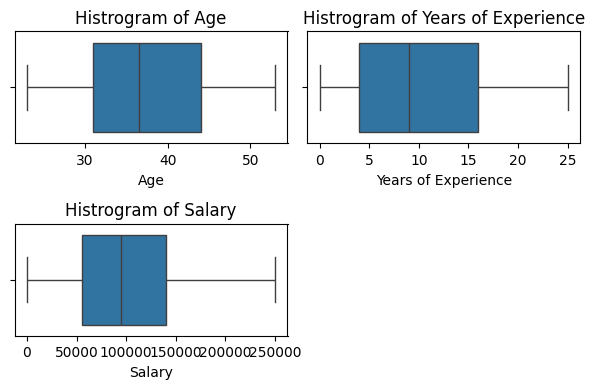

In [12]:
data = ["Age","Years of Experience","Salary"]

plt.figure(figsize=(6,4))

for inx, model in enumerate(data):
    plt.subplot(2,2, inx+1)
    sns.boxplot(data=df, x=model)
    plt.title(f"Histrogram of {model}")

plt.tight_layout()
plt.show()

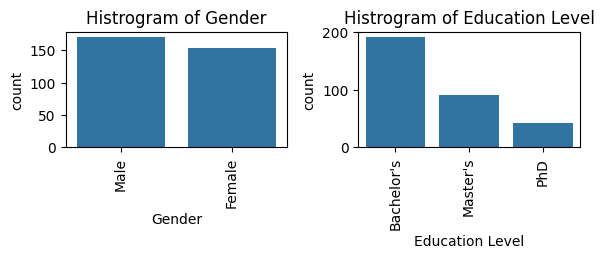

Total unique jobs: 174


In [13]:
data = ['Gender', 'Education Level']

plt.figure(figsize=(6,4))

for inx, model in enumerate(data):
    plt.subplot(2,2, inx+1)
    sns.countplot(data=df, x=model)
    plt.title(f"Histrogram of {model}")
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

print("Total unique jobs:",len(df["Job Title"].unique()))

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_columns = ['Gender', 'Education Level',"Job Title"]
numerical_columns = ["Age","Years of Experience"]

processor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first",handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns)
    ]
)

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

X_train = processor.fit_transform(X_train)
X_test = processor.transform(X_test)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "LR": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=6),
    "RFR": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    print(f"=========={name}===========")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2-Score:", r2_score(y_test, y_pred))
    

==========LR===========
MAE: 11127.726681003809
MSE: 235022797.41724142
R2-Score: 0.8756352966631166
==========KNN===========
MAE: 9947.820512820512
MSE: 161437018.16239312
R2-Score: 0.914573960092417
==========RFR===========
MAE: 10299.487179487181
MSE: 227119303.93162397
R2-Score: 0.8798175106162541


In [17]:
new_data = pd.DataFrame({
    "Age": [29],
    "Gender": ["Male"],
    "Education Level": ["Bachelor's"],
    "Job Title": ["Software Engineer"],
    "Years of Experience": [4]
})

data = processor.transform(new_data)
print(f"Predicted salary: {models["KNN"].predict(data)}")

Predicted salary: [54166.66666667]


# Saving the model and processor

In [18]:
import joblib

knn_model = models['KNN']

print(joblib.dump(knn_model, "knn_model.joblib"))
print(joblib.dump(processor, "processor.joblib"))


['knn_model.joblib']
['processor.joblib']


In [20]:
!pip show scikit-learn 

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: category_encoders, imbalanced-learn, mlxtend, sklearn-compat
